# Project 1: Sales CSV Cleaner

This notebook demonstrates the full data cleaning pipeline for sales CSV files.

売上CSVに含まれる **重複・欠損・不正値** を自動で除去し、整形済みデータとグラフを出力するまでの過程を示します。

---

In [1]:
%matplotlib inline
import sys
import logging
import warnings
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, 'src')
from cleaner import load_csv, clean, save_csv

warnings.filterwarnings('ignore')
print('Setup complete.')

Setup complete.


## 1. Raw Data — Before Cleaning / クレンジング前のデータ

The input file contains **8 rows** with the following intentional quality issues:

| Issue | Row | Detail |
|-------|-----|--------|
| Duplicate | 001 & 003 | Exact same record repeated |
| Duplicate | 002 & 006 | Exact same record repeated |
| Missing value | 004 | `amount` is blank |
| Invalid value | 007 | `amount` is -500 (negative) |

In [2]:
logging.disable(logging.CRITICAL)   # suppress logs for clean display
df_raw = load_csv('data/sales_sample.csv')
logging.disable(logging.NOTSET)

print(f'Rows: {len(df_raw)}')
df_raw

Rows: 8


,order_id,customer,amount,date,category
0,1,田中太郎,1500.0,2024-01-10,food
1,2,鈴木花子,3200.0,2024-01-11,electronics
2,3,田中太郎,1500.0,2024-01-10,food
3,4,佐藤一郎,NaN,2024-01-12,food
4,5,山田次郎,2800.0,2024-01-13,clothing
5,6,鈴木花子,3200.0,2024-01-11,electronics
6,7,高橋三郎,-500.0,2024-01-14,food
7,8,伊藤四郎,4100.0,2024-01-15,electronics


### Data Quality Check / 問題箇所の確認

In [3]:
print('=== Duplicated rows ===')
print(df_raw[df_raw.duplicated(keep=False)].to_string())

print('\n=== Missing values ===')
print(df_raw[df_raw['amount'].isna() | (df_raw['amount'] == '')])

print('\n=== Rows with amount <= 0 (after numeric conversion) ===')
_tmp = df_raw.copy()
_tmp['amount'] = pd.to_numeric(_tmp['amount'], errors='coerce')
print(_tmp[_tmp['amount'] <= 0])

=== Duplicated rows ===
Empty DataFrame
Columns: [order_id, customer, amount, date, category]
Index: []

=== Missing values ===
   order_id customer  amount        date category
3         4     佐藤一郎     NaN  2024-01-12     food

=== Rows with amount <= 0 (after numeric conversion) ===
   order_id customer  amount        date category
6         7     高橋三郎  -500.0  2024-01-14     food


---
## 2. Cleaning Pipeline / クレンジング処理

The `clean()` function applies the following steps in order:

1. **Drop duplicates** — remove rows where all columns match
2. **Remove null amounts** — `pd.to_numeric(errors='coerce')` + `dropna()`
3. **Remove invalid amounts** — filter `amount > 0`
4. **Normalize** — strip whitespace from `customer`, lowercase `category`
5. **Reorder columns** — `order_id → date → customer → category → amount`
6. **Sort by date** — ascending

In [4]:
# Run with logging visible to show each step
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)
df_clean = clean(df_raw.copy())

INFO: 重複削除: 0行削除


INFO: 欠損値(amount)除外後: 7行


INFO: 不正値除外: 1行削除


INFO: クレンジング完了: 6行


---
## 3. Cleaned Data — After / クレンジング後のデータ

In [5]:
logging.disable(logging.CRITICAL)
print(f'Before: {len(df_raw)} rows  →  After: {len(df_clean)} rows  ({len(df_raw)-len(df_clean)} removed)')
df_clean

Before: 8 rows  →  After: 6 rows  (2 removed)


,order_id,date,customer,category,amount
0,1,2024-01-10,田中太郎,food,1500.0
1,3,2024-01-10,田中太郎,food,1500.0
2,2,2024-01-11,鈴木花子,electronics,3200.0
3,6,2024-01-11,鈴木花子,electronics,3200.0
4,5,2024-01-13,山田次郎,clothing,2800.0
5,8,2024-01-15,伊藤四郎,electronics,4100.0


---
## 4. Visualization / 可視化

Two charts are generated from the cleaned data.

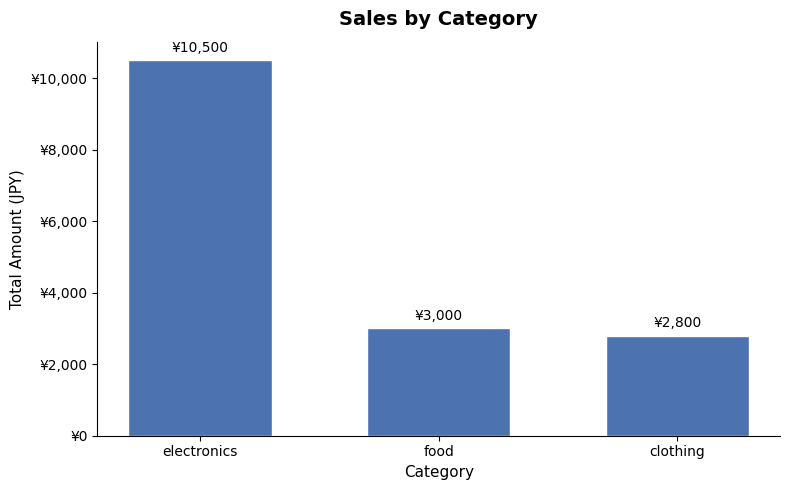

In [6]:
# Bar chart: total sales by category
totals = df_clean.groupby('category')['amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(totals.index, totals.values, color='#4C72B0', edgecolor='white', width=0.6)
ax.bar_label(bars, labels=[f'¥{v:,.0f}' for v in totals.values], padding=4, fontsize=10)
ax.set_title('Sales by Category', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Total Amount (JPY)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'¥{x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

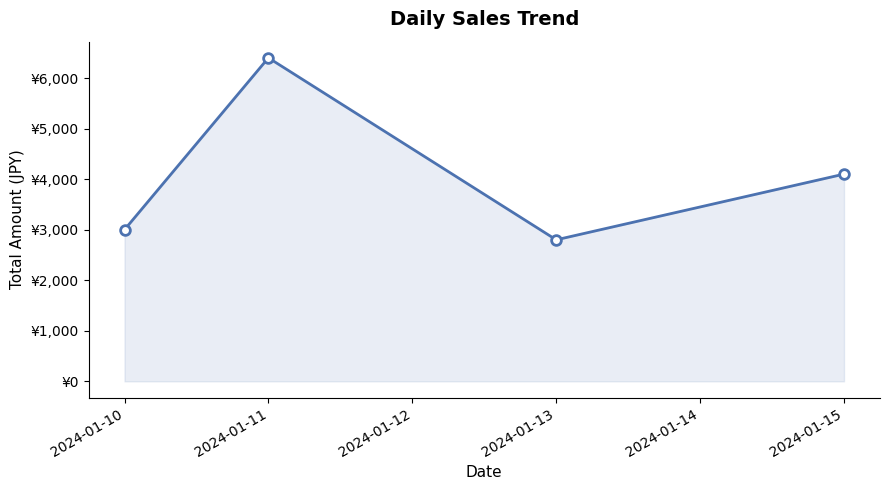

In [7]:
# Line chart: daily sales trend
daily = df_clean.groupby('date')['amount'].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(daily['date'], daily['amount'],
        marker='o', linewidth=2, color='#4C72B0',
        markersize=7, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(daily['date'], daily['amount'], alpha=0.12, color='#4C72B0')
ax.set_title('Daily Sales Trend', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total Amount (JPY)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'¥{x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Save Output / 出力保存

In [8]:
logging.disable(logging.NOTSET)
save_csv(df_clean, 'data/sales_cleaned.csv')
print('Done. Cleaned CSV saved to data/sales_cleaned.csv')

INFO: 出力完了: data/sales_cleaned.csv


Done. Cleaned CSV saved to data/sales_cleaned.csv
